In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import math

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay, f1_score


In [2]:
pd.options.display.float_format = '{:.2f}'.format

### Data load

In [3]:
df = pd.read_csv("data/medical_insurance.csv")


### Functions

In [4]:
def plot_categories_distribution_charts_on_common_grid(df, cols):

    plots_number = len(cols)
    plots_in_a_row_number = 3
    number_of_plot_rows = math.ceil(plots_number / plots_in_a_row_number)

    fig, axs = plt.subplots(number_of_plot_rows, plots_in_a_row_number, figsize=(15, 5 * number_of_plot_rows))
    axs = axs.flatten() 

    for i, col in enumerate(cols):
        classVals, classCnts = np.unique(df[col].dropna(), return_counts=True)

        x_pos = np.arange(len(classVals))
        axs[i].bar(x_pos, classCnts)

        # set the ticks
        axs[i].set_xticks(x_pos)
        axs[i].set_xticklabels(classVals, rotation=45, ha='right')

        axs[i].set_xlabel("Category")
        axs[i].set_ylabel("Samples")
        axs[i].set_title(f"{col} distribution", fontsize=10)
        axs[i].grid(True, axis='y', linestyle='--', alpha=0.7)

    # Hide empty axis
    for j in range(plots_number, len(axs)):
        axs[j].set_visible(False)

    plt.tight_layout()
    plt.show()


In [5]:
def prediction_evaluation(
        X_train,
        X_test,
        y_train,
        y_test,
        model      
):
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc_score_train = accuracy_score(y_train, model.predict(X_train))
    acc_score = accuracy_score(y_test, y_pred)
    f1_score_train = f1_score(y_train, model.predict(X_train))

    print(f"Accuracy score train: {acc_score_train}\nAccuracy score test: {acc_score}")
    print(classification_report(y_test, y_pred))
    print(f"f1 score train: {f1_score_train}")

    cm_df = pd.DataFrame(confusion_matrix(y_test, y_pred), index=['True: 0', 'True: 1'], columns=['Pred: 0', 'Pred: 1'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='g')
    plt.title('Confusion matrix')
    plt.xlabel('Predictions')
    plt.ylabel('Actual values')
    plt.show()

    pred_train_proba = model.predict_proba(X_train)[:,1]
    pred_test_proba = model.predict_proba(X_test)[:,1]

    print(f"AUC train: {roc_auc_score(y_train,pred_train_proba)}")
    print(f"AUC test: {roc_auc_score(y_test,pred_test_proba)}")
    RocCurveDisplay.from_predictions(y_test, pred_test_proba)
    plt.show()

    return y_pred

In [6]:
def plot_categories_count(df,col):
    classVals, classCnts = np.unique(df[col], return_counts=True)
    plt.figure(figsize=(8,6))
    plt.bar(classVals, classCnts)
    plt.xlabel("category")
    plt.ylabel("samples")
    plt.title(f"{col} distribution")
    plt.show()

### EDA

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

Conclusion: alcohol_freq has many NaNs. Considering the fact the dataset is rich in variables, I won't include alcohol_freq in the analysis.

In [8]:
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.00,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.00,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.00,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.00,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.00,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [9]:
df["person_id"].nunique()

100000

Conlusion: No duplicates in data
***

In [10]:
socioeconomic_variables = [
    "age",
    "sex",
    "region",
    "urban_rural",
    "income",
    "education",
    "marital_status",
    "employment_status",
    "household_size",
    "dependents"
]

lifestyle_variables = [
    'bmi',
    "smoker",
    # "alcohol_freq", # excluded from analysis
]

health_variables = [
    "hypertension",
    "diabetes",
    "copd",
    "cardiovascular_disease",
    "cancer_history",
    "kidney_disease",
    "liver_disease",
    "arthritis",
    "mental_health",
    "chronic_count",
    "systolic_bp",
    "diastolic_bp",
    "ldl",
    "hba1c",
]

healthcare_variables = [
    "visits_last_year",
    "hospitalizations_last_3yrs",
    "days_hospitalized_last_3yrs",
    "medication_count",
    "proc_imaging_count",
    "proc_surgery_count",
    "proc_physio_count",
    "proc_consult_count",
    'proc_lab_count',
    "had_major_procedure",    
]

insurance_variables = [
    "plan_type",
    "network_tier",
    "deductible",
    "copay",
    "policy_term_years",
    "policy_changes_last_2yrs",
    "provider_quality"
]

medical_cost_variables = [
    "annual_medical_cost",
    "annual_premium",
    "monthly_premium",
    "claims_count",
    "avg_claim_amount",
    "total_claims_paid"
]

regression_target = "risk_score"
classification_target = "is_high_risk"

***

#### socioeconomic variables - values

In [11]:
df[socioeconomic_variables].head()

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents
0,52,Female,North,Suburban,22700.00,Doctorate,Married,Retired,3,1
1,79,Female,North,Urban,12800.00,No HS,Married,Employed,3,1
2,68,Male,North,Rural,40700.00,HS,Married,Retired,5,3
3,15,Male,North,Suburban,15600.00,Some College,Married,Self-employed,5,3
4,53,Male,Central,Suburban,89600.00,Doctorate,Married,Self-employed,2,0


In [12]:
for var in socioeconomic_variables:
    print(f"Number of {var}'s unique values: {df[var].nunique()}")

Number of age's unique values: 101
Number of sex's unique values: 3
Number of region's unique values: 5
Number of urban_rural's unique values: 3
Number of income's unique values: 2987
Number of education's unique values: 6
Number of marital_status's unique values: 4
Number of employment_status's unique values: 4
Number of household_size's unique values: 9
Number of dependents's unique values: 8


In [13]:
# categorical
for categorical_var in [categorical_var for categorical_var in socioeconomic_variables[1:-2] if categorical_var != "income"]:
    print(f"{categorical_var}'s values: {df[categorical_var].unique()}")

sex's values: ['Female' 'Male' 'Other']
region's values: ['North' 'Central' 'West' 'South' 'East']
urban_rural's values: ['Suburban' 'Urban' 'Rural']
education's values: ['Doctorate' 'No HS' 'HS' 'Some College' 'Masters' 'Bachelors']
marital_status's values: ['Married' 'Single' 'Divorced' 'Widowed']
employment_status's values: ['Retired' 'Employed' 'Self-employed' 'Unemployed']


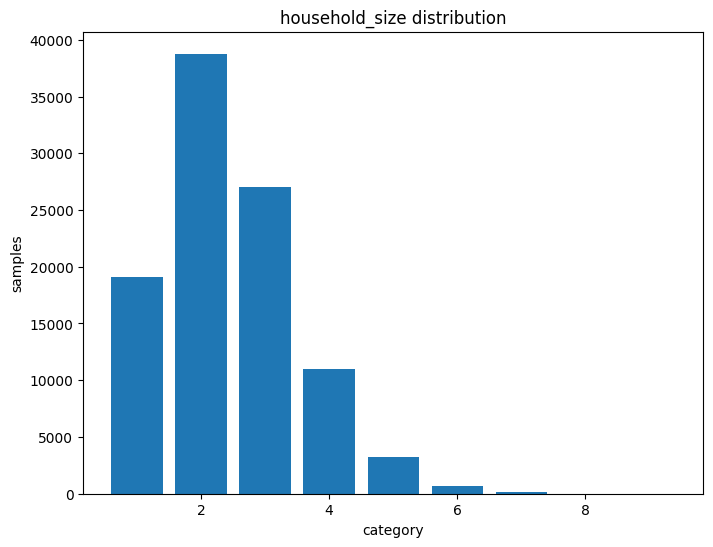

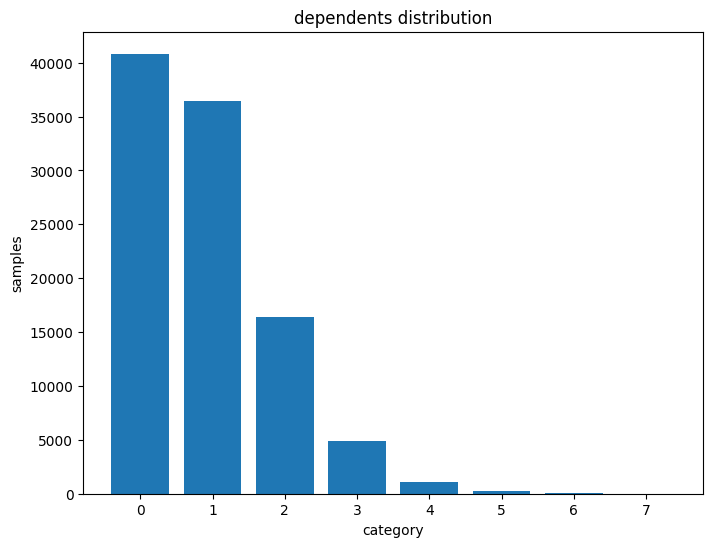

In [14]:
# numerical
for col in ["household_size", "dependents"]:
    plot_categories_count(df,col)

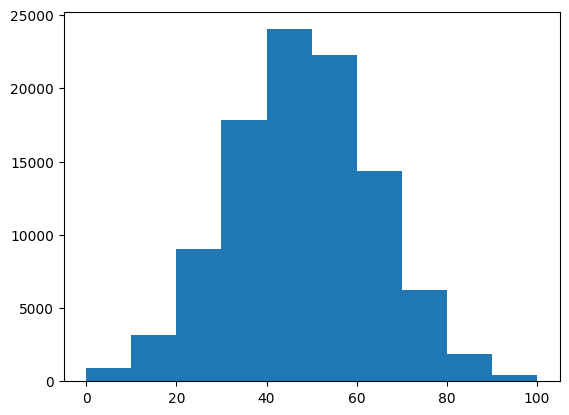

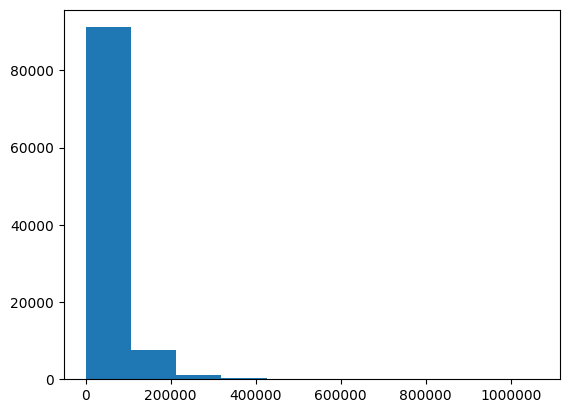

In [15]:
for col in ["age", "income"]:
    plt.hist(df[col])
    plt.ticklabel_format(style='plain', axis='x')
    plt.show()

In [16]:
df[["age", "income"]].describe()

,age,income
count,100000.00,100000.00
mean,47.52,49873.90
std,15.99,46800.21
min,0.00,1100.00
25%,37.00,21100.00
50%,48.00,36200.00
75%,58.00,62200.00
max,100.00,1061800.00


In [17]:
df.loc[df["age"]==0, socioeconomic_variables + lifestyle_variables].head()

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker
368,0,Female,South,Suburban,68300.00,Masters,Single,Employed,2,1,27.90,Never
1815,0,Female,West,Rural,103200.00,Doctorate,Married,Self-employed,3,1,23.70,Never
2420,0,Male,Central,Urban,65200.00,Masters,Married,Employed,3,1,25.30,Never
2740,0,Female,South,Urban,4800.00,Masters,Married,Employed,4,2,25.30,Never
2769,0,Male,South,Urban,47700.00,Some College,Single,Employed,1,0,29.50,Never


In [18]:
df.loc[df["age"]==0, "smoker"].unique()

array(['Never', 'Former', 'Current'], dtype=object)

In [19]:
df.loc[df["age"]==0, "employment_status"].unique()

array(['Employed', 'Self-employed', 'Retired', 'Unemployed'], dtype=object)

Conclusion: According to data, 0 year old customers have income, education, can be married, retired and smoking.

In [20]:
df_minors = df.loc[df["age"]<18]
for var in ["education", "marital_status", "employment_status"]:
    print(df_minors[var].unique())

['Some College' 'Masters' 'Bachelors' 'HS' 'No HS' 'Doctorate']
['Married' 'Divorced' 'Single' 'Widowed']
['Self-employed' 'Employed' 'Retired' 'Unemployed']


In [21]:
df_1st_decade_children = df.loc[df["age"].between(1,10)]
for var in ["education", "marital_status", "employment_status"]:
    print(df_1st_decade_children[var].unique())

['Some College' 'No HS' 'HS' 'Bachelors' 'Masters' 'Doctorate']
['Single' 'Married' 'Divorced' 'Widowed']
['Employed' 'Self-employed' 'Unemployed' 'Retired']


Conclusion: the variable 'age' is unreliable, therefore it will be excluded from the analysis.

In [22]:
socioeconomic_variables.remove("age")

***

#### lifestyle variables - values

In [23]:
df[lifestyle_variables].tail()

,bmi,smoker
99995,28.20,Never
99996,27.60,Never
99997,29.80,Former
99998,21.90,Never
99999,29.20,Never


In [24]:
df["bmi"].describe()

count   100000.00
mean        26.99
std          4.99
min         12.00
25%         23.60
50%         27.00
75%         30.40
max         50.40
Name: bmi, dtype: float64

Conclusion: According to [Wikipedia](https://en.wikipedia.org/wiki/Body_mass_index), the values are reasonable. \
Creating a categorical bmi variable is an option to consider.

***

#### health variables - values

In [25]:
df[health_variables].head()

,hypertension,diabetes,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,chronic_count,systolic_bp,diastolic_bp,ldl,hba1c
0,0,0,0,0,0,0,0,1,0,1,121.00,76.00,123.80,5.28
1,0,0,0,0,0,0,0,1,1,2,131.00,79.00,97.30,4.82
2,1,0,0,0,1,0,0,0,1,3,160.00,84.00,129.50,5.51
3,0,1,0,0,0,0,0,0,0,1,104.00,68.00,160.30,8.50
4,1,0,0,0,0,0,0,1,0,2,136.00,83.00,171.00,5.20


In [26]:
df[health_variables].describe()

,hypertension,diabetes,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,chronic_count,systolic_bp,diastolic_bp,ldl,hba1c
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,0.20,0.09,0.04,0.05,0.02,0.01,0.01,0.11,0.13,0.72,117.81,73.60,119.98,5.61
std,0.40,0.28,0.19,0.22,0.15,0.12,0.12,0.31,0.34,0.81,15.37,8.90,30.26,0.85
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,61.00,40.00,30.00,3.54
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,107.00,67.00,99.40,5.16
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,117.00,73.00,120.00,5.44
75%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,128.00,79.00,140.30,5.76
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,6.00,183.00,114.00,248.30,11.94


Conclusion: According to [Blood Pressure Page](https://my.clevelandclinic.org/health/diagnostics/17649-blood-pressure), systolic bp above 180 means Hypertensive crisis (urgency or emergency), so maximum systolic_bp = 183 is a little bit suspicious, but whether it's an incorrect value depends on circumstnces of bp measurement. For this analysis we acknowledge this value as correct. \
Maximum value of diastolic_bp = 114 is correct. \
Minimum values 61 and 40 of respectively systolic_bp and diastolic_bp are possible but most likely are related to life-threatening conditions. \
Since the circumstances under which the data was obtained are unknown, for this analysis I assume that the data is correct. \
According to sources, ldl and hba1c values are reliable.

***

***

## Classification

#### Target analysis

In [27]:
df[classification_target].value_counts()

is_high_risk
0    63219
1    36781
Name: count, dtype: int64

In [28]:
# % distribution
df[classification_target].value_counts()/len(df[classification_target])*100

is_high_risk
0   63.22
1   36.78
Name: count, dtype: float64

In [29]:
for category in df[classification_target].unique():
    print(f"distribution of {regression_target} for the category {category}")
    display(df.loc[df[classification_target] == category, regression_target].describe())

distribution of risk_score for the category 0


count   63219.00
mean        0.36
std         0.15
min         0.00
25%         0.25
50%         0.37
75%         0.48
max         0.59
Name: risk_score, dtype: float64

distribution of risk_score for the category 1


count   36781.00
mean        0.79
std         0.13
min         0.60
25%         0.67
50%         0.77
75%         0.90
max         1.00
Name: risk_score, dtype: float64

Conclusion: \
risk score < 60 -> low risk \
risk score > 60 -> high risk

#### Healthcare variables analysis

In [30]:
df[healthcare_variables].head()

,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,had_major_procedure
0,2,0,0,4,1,0,2,0,1,0
1,2,0,0,3,0,0,1,0,1,0
2,1,0,0,4,1,0,2,1,0,0
3,0,0,0,1,1,0,0,1,0,0
4,3,0,0,2,2,0,1,1,0,0


In [31]:
df[healthcare_variables].describe()

,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,had_major_procedure
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,1.93,0.09,0.37,1.24,0.51,0.16,0.51,0.51,0.51,0.17
std,1.74,0.30,1.37,1.21,0.75,0.46,0.75,0.75,0.75,0.38
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,2.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,3.00,0.00,0.00,2.00,1.00,0.00,1.00,1.00,1.00,0.00
max,25.00,3.00,21.00,11.00,7.00,6.00,7.00,7.00,7.00,1.00


Conclusion: as we could have suspected, most customers had few medical procedures.

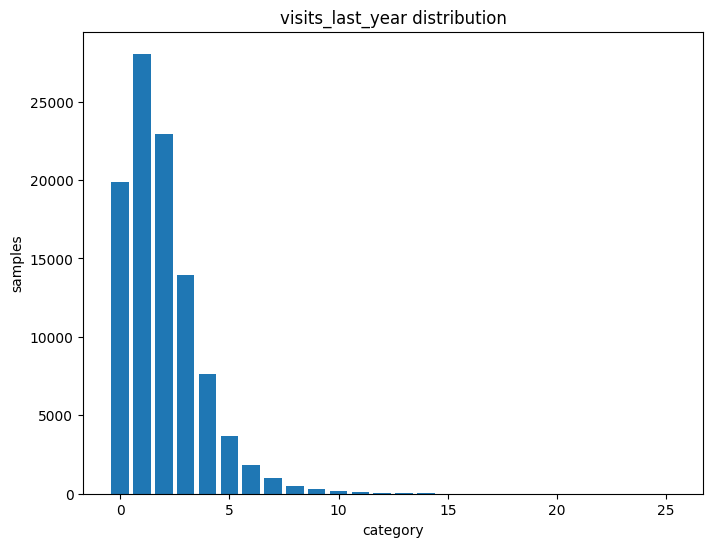

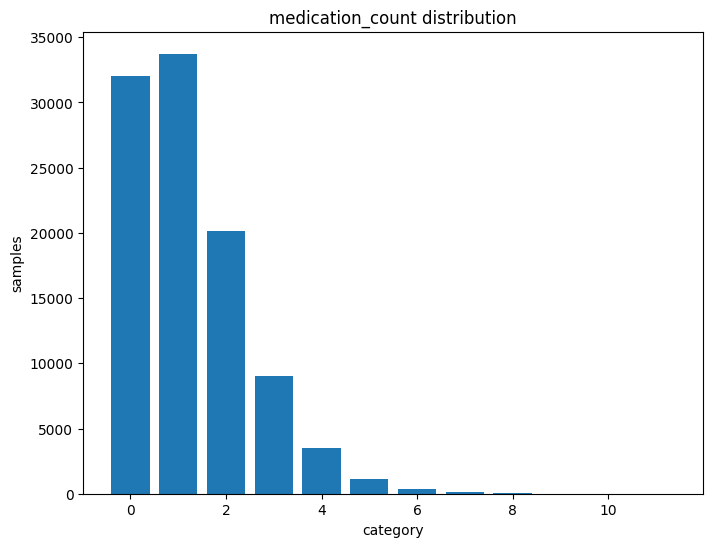

In [32]:
# deepen analysis of visits_last_year and medication_count
for col in ["visits_last_year", "medication_count"]:
    plot_categories_count(df,col)

#### Health variables analysis

In [33]:
df[health_variables].head()

,hypertension,diabetes,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,chronic_count,systolic_bp,diastolic_bp,ldl,hba1c
0,0,0,0,0,0,0,0,1,0,1,121.00,76.00,123.80,5.28
1,0,0,0,0,0,0,0,1,1,2,131.00,79.00,97.30,4.82
2,1,0,0,0,1,0,0,0,1,3,160.00,84.00,129.50,5.51
3,0,1,0,0,0,0,0,0,0,1,104.00,68.00,160.30,8.50
4,1,0,0,0,0,0,0,1,0,2,136.00,83.00,171.00,5.20


In [34]:
df[health_variables[-4:]].describe()

,systolic_bp,diastolic_bp,ldl,hba1c
count,100000.00,100000.00,100000.00,100000.00
mean,117.81,73.60,119.98,5.61
std,15.37,8.90,30.26,0.85
min,61.00,40.00,30.00,3.54
25%,107.00,67.00,99.40,5.16
50%,117.00,73.00,120.00,5.44
75%,128.00,79.00,140.30,5.76
max,183.00,114.00,248.30,11.94


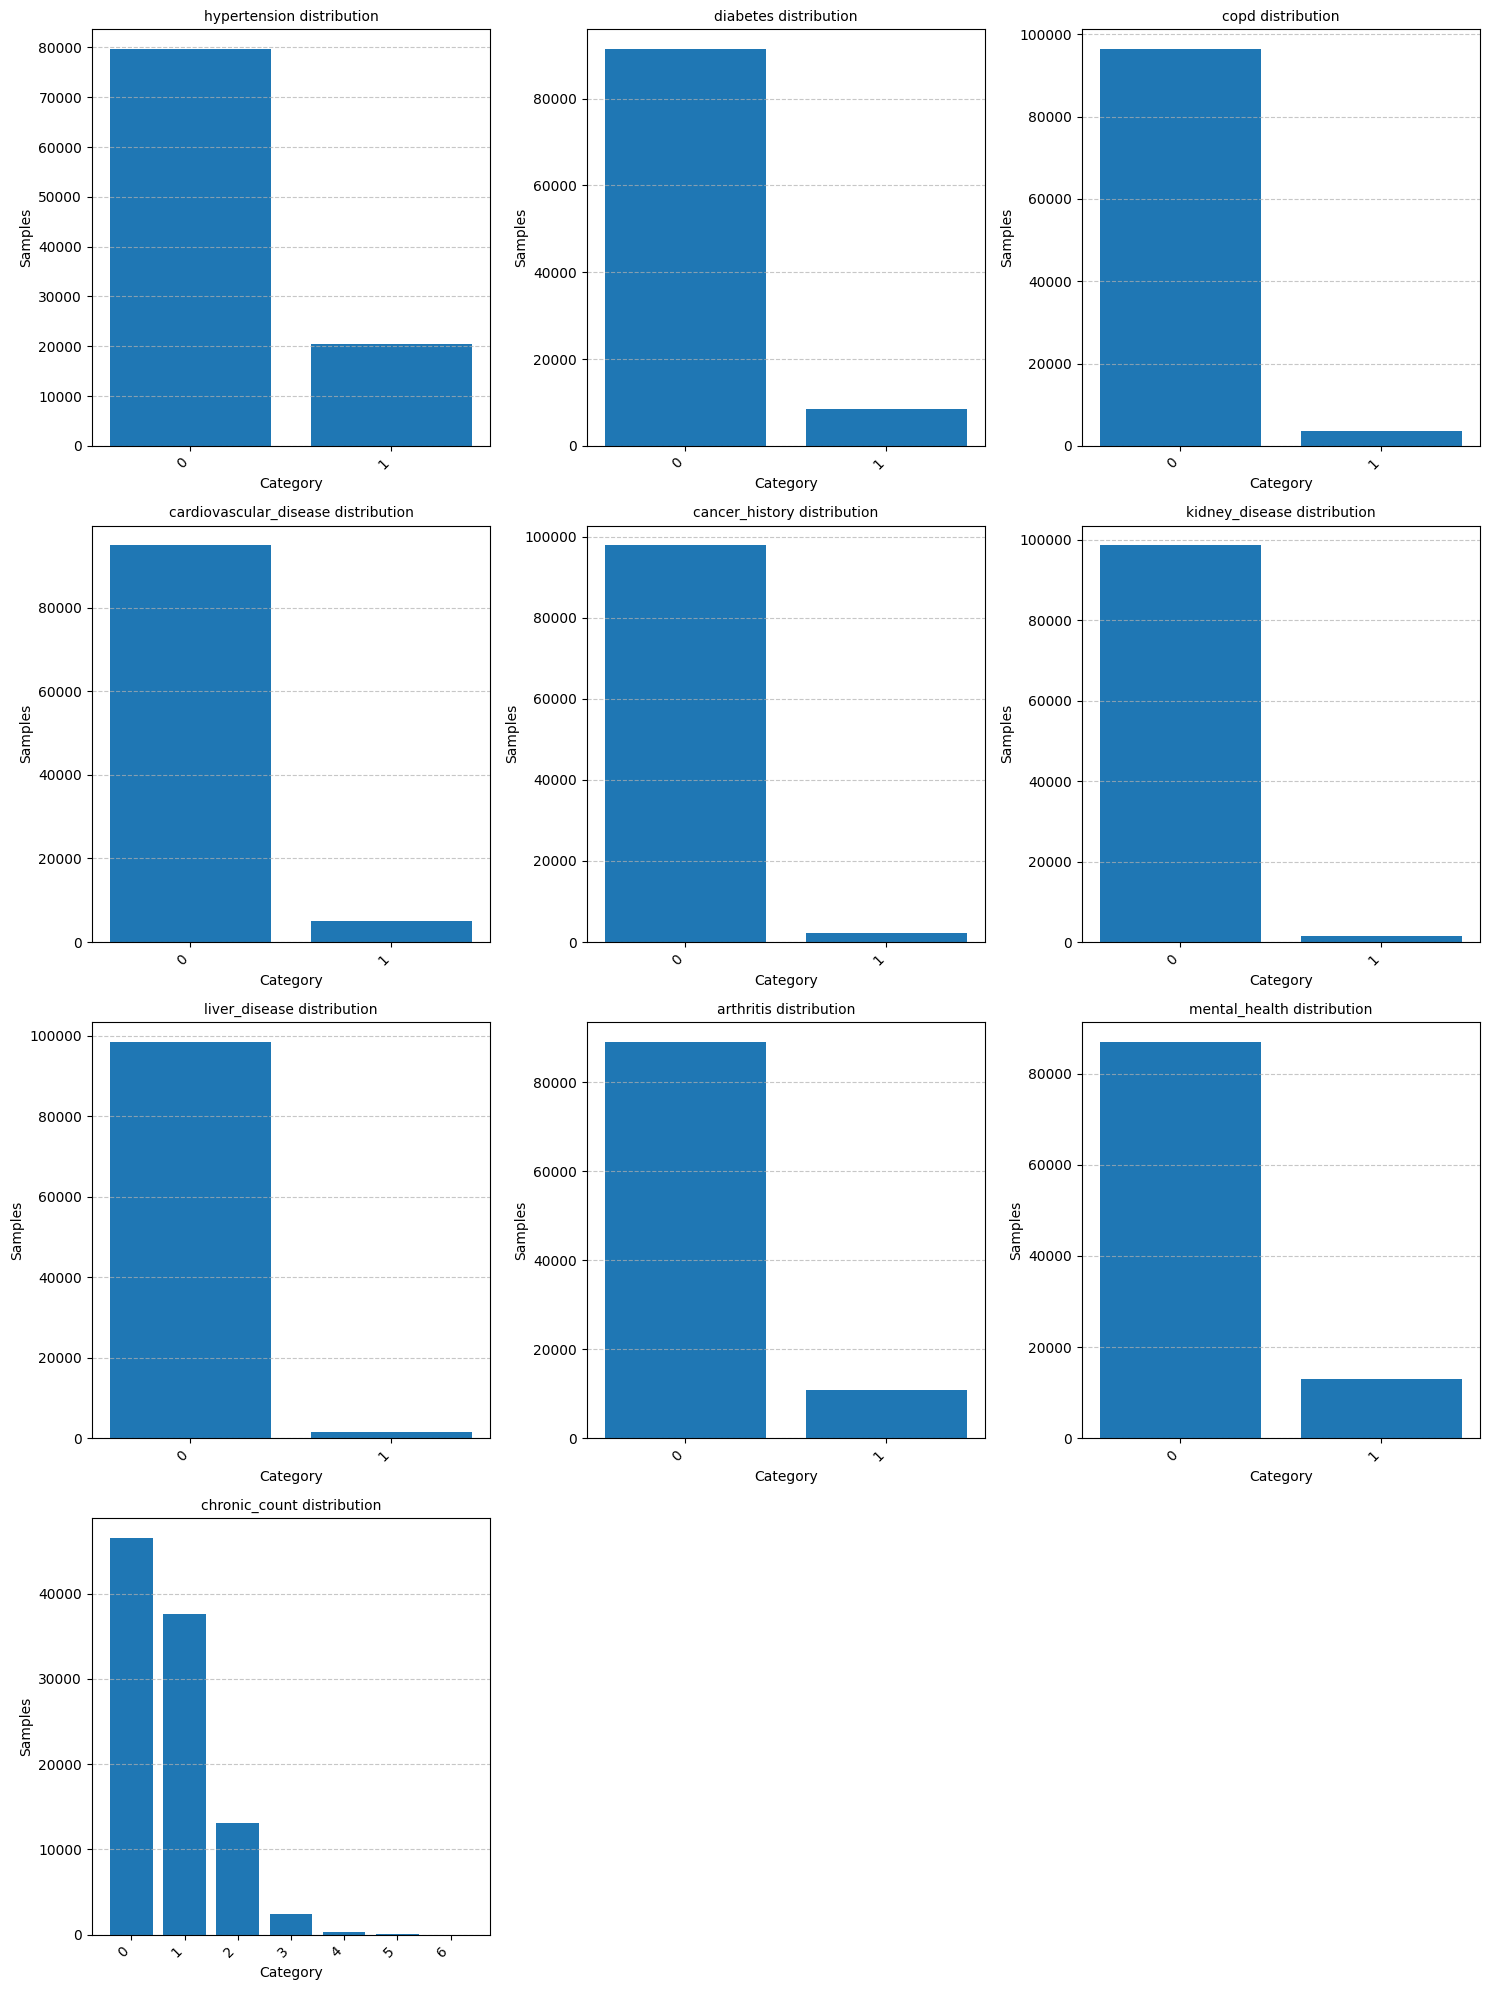

In [35]:
plot_categories_distribution_charts_on_common_grid(df, health_variables[:-4])

### Correlation

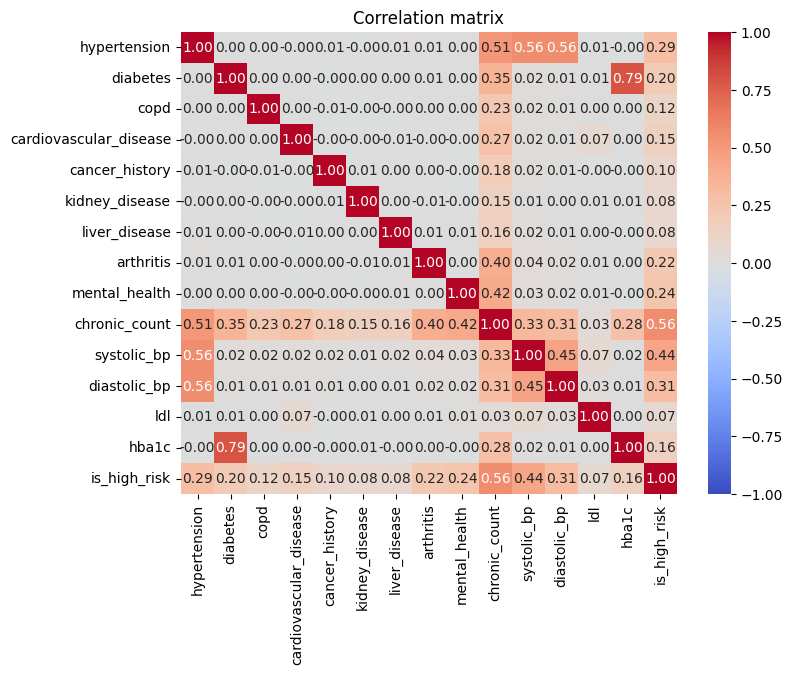

In [36]:
corr_matrix = df[health_variables + [classification_target]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation matrix')
plt.show()

Conclusion: as we could have suspected, number of chronical deceases (chronic_count) is the most correlated with the target.

***

#### Encoding the variables

In [37]:
# reminder
for categorical_var in [categorical_var for categorical_var in socioeconomic_variables[:-2] if categorical_var != "income"]:
    print(f"{categorical_var}'s values: {df[categorical_var].unique()}")

sex's values: ['Female' 'Male' 'Other']
region's values: ['North' 'Central' 'West' 'South' 'East']
urban_rural's values: ['Suburban' 'Urban' 'Rural']
education's values: ['Doctorate' 'No HS' 'HS' 'Some College' 'Masters' 'Bachelors']
marital_status's values: ['Married' 'Single' 'Divorced' 'Widowed']
employment_status's values: ['Retired' 'Employed' 'Self-employed' 'Unemployed']


In [38]:
df["smoker"].unique()

array(['Never', 'Current', 'Former'], dtype=object)

In [39]:
# Ordinal encoder
to_ordinal_encode = ["urban_rural", "education", "smoker"]
categories = [
    ["Urban", "Suburban", "Rural"],
    ["No HS", "HS", "Some College", "Masters", "Bachelors", "Doctorate"],
    ["Never", "Current", "Former"]
]

ordinal_encoder = OrdinalEncoder(categories=categories)
ordinal_encoded = ordinal_encoder.fit_transform(df[to_ordinal_encode])
df_ordinal_encoded = pd.DataFrame(ordinal_encoded, columns=[col + "_encoded" for col in to_ordinal_encode])

# Label encoder
to_encode = ["sex", "region", "marital_status", "employment_status"]

label_encoder = LabelEncoder()
for col in to_encode:
    df[col + "_encoded"] = label_encoder.fit_transform(df[col])



# encoded data
df = pd.concat([df, df_ordinal_encoded], axis=1)

In [40]:
df.iloc[:5,-7:]

,sex_encoded,region_encoded,marital_status_encoded,employment_status_encoded,urban_rural_encoded,education_encoded,smoker_encoded
0,0,2,1,1,1.00,5.00,0.00
1,0,2,1,0,0.00,0.00,0.00
2,1,2,1,1,2.00,1.00,0.00
3,1,2,1,2,1.00,2.00,0.00
4,1,0,1,2,1.00,5.00,0.00


In [41]:
# update list of variables
socioeconomic_variables = [
    "sex_encoded",
    "region_encoded",
    "urban_rural_encoded",
    "income",
    "education_encoded",
    "marital_status_encoded",
    "employment_status_encoded",
    "household_size",
    "dependents"
]

lifestyle_variables = [
    'bmi',
    "smoker_encoded",
]

### Train test split

In [42]:
X = df[
socioeconomic_variables
+ lifestyle_variables
+ health_variables
+ healthcare_variables
+ insurance_variables
+ medical_cost_variables
]
y_classification = df[classification_target]
y_regression = df[regression_target]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y_classification, test_size = 0.3, random_state = 1)

In [44]:
# target distribution in train and test dataset
y_train.value_counts()/len(y_train)*100, y_test.value_counts()/len(y_test)*100

(is_high_risk
 0   63.30
 1   36.70
 Name: count, dtype: float64,
 is_high_risk
 0   63.02
 1   36.98
 Name: count, dtype: float64)

### The metric

Considering the data, accuracy, AUC and f1-score are good metrics to monitor. \
Precision and recall can be complementary metrics; especially precision, as high risk customers cost the company more than low risk customers.

### XGboost

#### benchmark

Accuracy score train: 0.8044714285714286
Accuracy score test: 0.7970666666666667
              precision    recall  f1-score   support

           0       0.82      0.87      0.84     18907
           1       0.75      0.68      0.71     11093

    accuracy                           0.80     30000
   macro avg       0.79      0.77      0.78     30000
weighted avg       0.79      0.80      0.79     30000

f1 score train: 0.7209525168708842


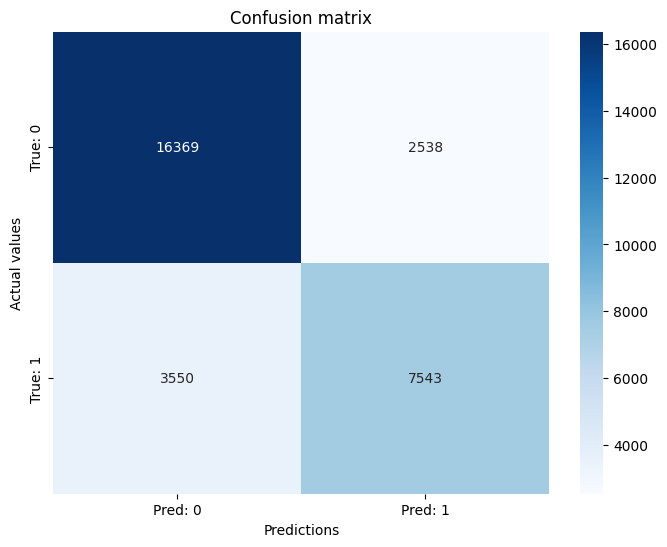

AUC train: 0.8800819848142014
AUC test: 0.8739682253183918


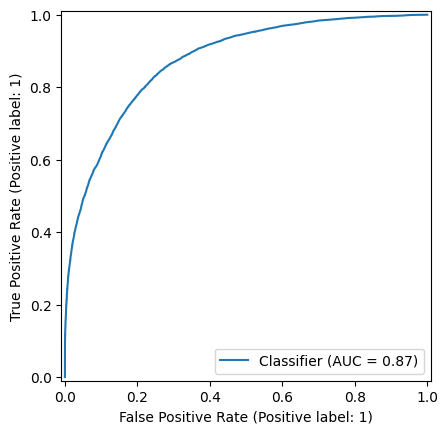

In [45]:
X_vars = ["chronic_count","systolic_bp", "diastolic_bp"]
model = xgb.XGBClassifier(objective='binary:logistic', random_state=1)
y_pred = prediction_evaluation(
    X_train[X_vars],
    X_test[X_vars],
    y_train,
    y_test,
    model
)

#### Version 1

Accuracy score train: 0.8224571428571429
Accuracy score test: 0.8178333333333333
              precision    recall  f1-score   support

           0       0.83      0.90      0.86     18907
           1       0.80      0.68      0.73     11093

    accuracy                           0.82     30000
   macro avg       0.81      0.79      0.80     30000
weighted avg       0.82      0.82      0.81     30000

f1 score train: 0.7390062581376791


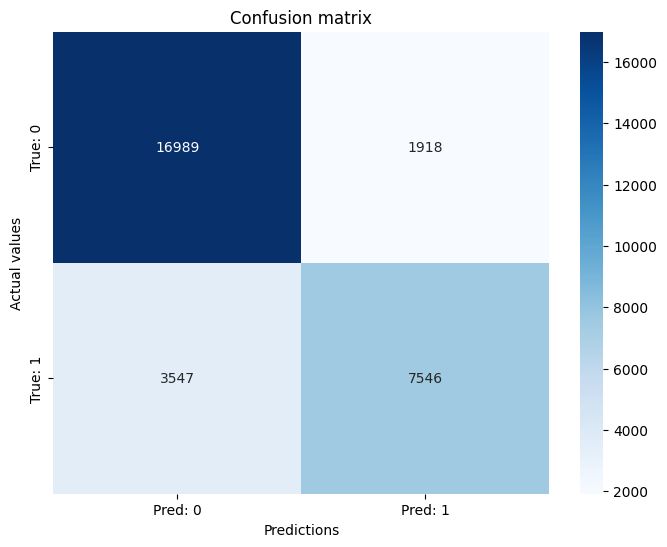

AUC train: 0.8927558867913146
AUC test: 0.8876429372175796


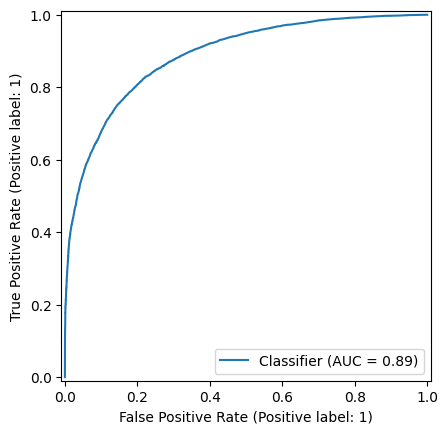

In [46]:
X_vars = ["chronic_count","systolic_bp", "diastolic_bp", "hypertension","diabetes"]
model = xgb.XGBClassifier(objective='binary:logistic', random_state=1)
y_pred = prediction_evaluation(
    X_train[X_vars],
    X_test[X_vars],
    y_train,
    y_test,
    model
)

#### Version 2

Accuracy score train: 0.8406
Accuracy score test: 0.8169
              precision    recall  f1-score   support

           0       0.83      0.89      0.86     18907
           1       0.79      0.69      0.74     11093

    accuracy                           0.82     30000
   macro avg       0.81      0.79      0.80     30000
weighted avg       0.81      0.82      0.81     30000

f1 score train: 0.7671535893155259


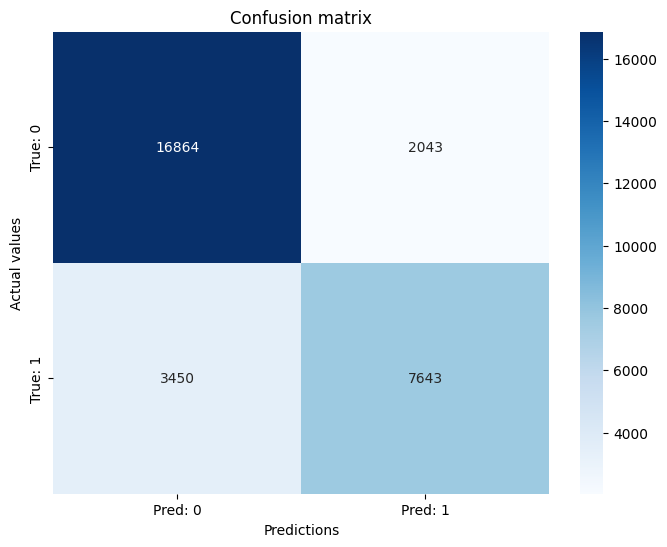

AUC train: 0.909634368937028
AUC test: 0.8862613055631237


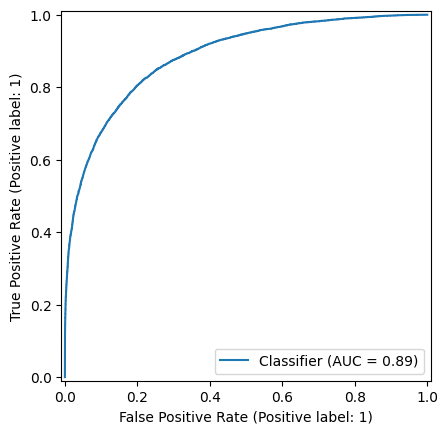

In [47]:
X_vars = health_variables
model = xgb.XGBClassifier(objective='binary:logistic', random_state=1)
y_pred = prediction_evaluation(
    X_train[X_vars],
    X_test[X_vars],
    y_train,
    y_test,
    model
)

Conclusion: the improvement is negligible.

#### Version 3

Accuracy score train: 0.8834714285714286
Accuracy score test: 0.8565333333333334
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     18907
           1       0.82      0.78      0.80     11093

    accuracy                           0.86     30000
   macro avg       0.85      0.84      0.84     30000
weighted avg       0.86      0.86      0.86     30000

f1 score train: 0.8367914524100122


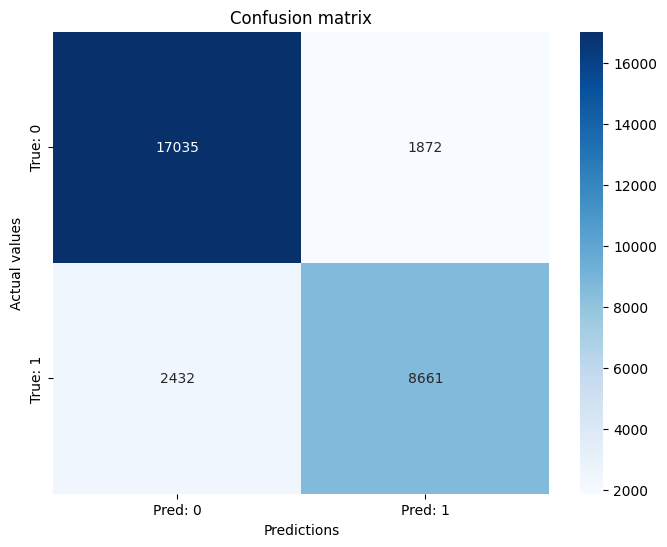

AUC train: 0.9522037698384473
AUC test: 0.9317692466636205


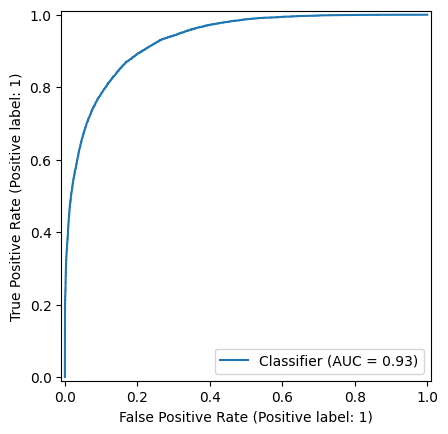

In [48]:
X_vars = health_variables + lifestyle_variables
model = xgb.XGBClassifier(objective='binary:logistic', random_state=1)
y_pred = prediction_evaluation(
    X_train[X_vars],
    X_test[X_vars],
    y_train,
    y_test,
    model
)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

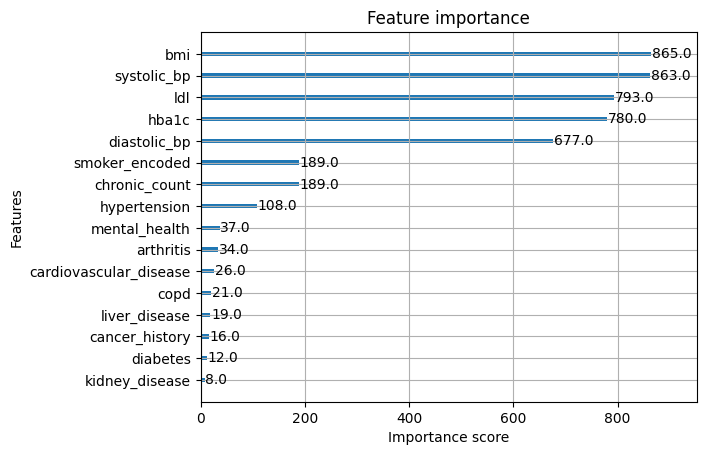

In [49]:
xgb.plot_importance(model)

Conclusion: the model is better than previous versions.

#### Version 4

Accuracy score train: 0.8917285714285714
Accuracy score test: 0.8565333333333334
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     18907
           1       0.82      0.78      0.80     11093

    accuracy                           0.86     30000
   macro avg       0.85      0.84      0.84     30000
weighted avg       0.86      0.86      0.86     30000

f1 score train: 0.8481801245968631


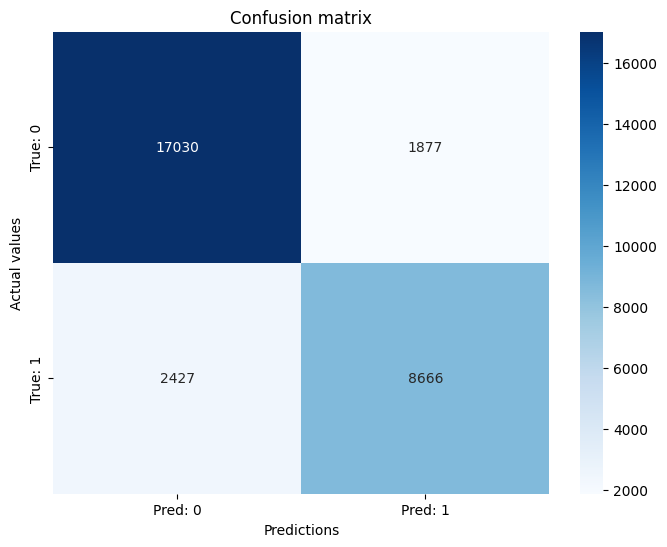

AUC train: 0.9587909607366951
AUC test: 0.931202961583715


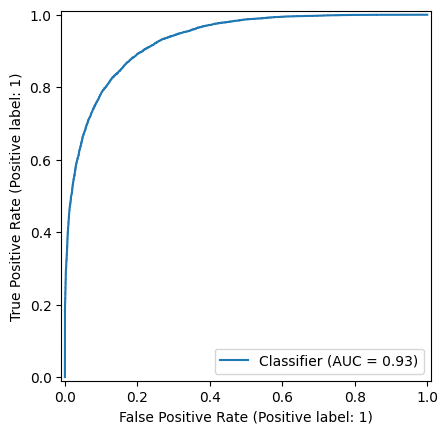

In [50]:
X_vars = health_variables + lifestyle_variables + medical_cost_variables
model = xgb.XGBClassifier(objective='binary:logistic', random_state=1)
y_pred = prediction_evaluation(
    X_train[X_vars],
    X_test[X_vars],
    y_train,
    y_test,
    model
)

Conclusion: The model hasn't improved comparing to version 3.

Version 5

Accuracy score train: 0.8898428571428572
Accuracy score test: 0.8555
              precision    recall  f1-score   support

           0       0.87      0.90      0.89     18907
           1       0.82      0.78      0.80     11093

    accuracy                           0.86     30000
   macro avg       0.85      0.84      0.84     30000
weighted avg       0.85      0.86      0.85     30000

f1 score train: 0.8456719703792654


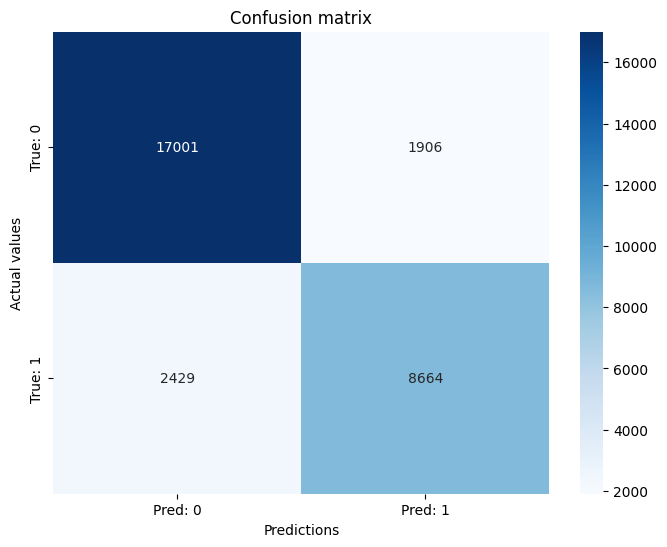

AUC train: 0.9568529515468553
AUC test: 0.9309101568671654


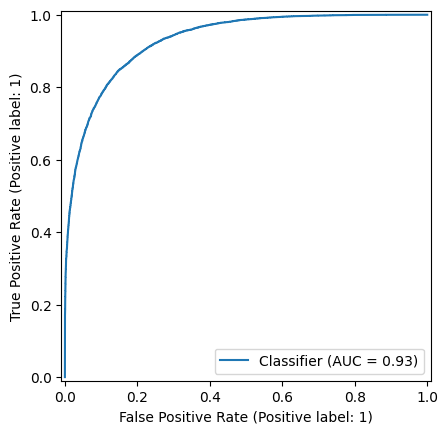

In [51]:
X_vars = health_variables + lifestyle_variables + socioeconomic_variables
model = xgb.XGBClassifier(objective='binary:logistic', random_state=1)
y_pred = prediction_evaluation(
    X_train[X_vars],
    X_test[X_vars],
    y_train,
    y_test,
    model
)

Conclusion: The model hasn't improved comparing to version 3.

***

#### The summary of experiments

I choose version 3 as the best model. It contains fewer variables than version 4 and 5, which decreases the complexity of the model, yet have better accuracy than version 1 and 2. \
Further, I'm tuning hyperparameters for version 3.

#### Hyperparameters tuning

In [52]:
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe 
from hyperopt.early_stop import no_progress_loss

data_dm = xgb.DMatrix(data=X_train[X_vars].values, label=y_train)

space = {
    'max_depth': hp.choice("max_depth", np.arange(3,8,1,dtype=int)),
    'eta'      : hp.uniform("eta", 0, 1),
    'gamma'    : hp.uniform("gamma", 0, 1),
    'colsample_bytree': hp.uniform("colsample_bytree", 0.5,1),
    'num_boost_round': hp.choice("num_boost_round", np.arange(10,100,2,dtype='int')),
    'subsample' : hp.uniform("subsample",0.5,1),
    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',
    'seed' : 1
}

def xgb_objective(space):
    num_boost_round = int(space['num_boost_round'])
    del space['num_boost_round']

    results = xgb.cv(
        space,
        dtrain=data_dm,
        num_boost_round=num_boost_round,
        nfold=5,
        stratified=True,
        early_stopping_rounds=20,
        metrics=['logloss','auc','aucpr','error']
    )

    best_score = results['test-auc-mean'].max()
    return {'loss': -best_score, 'status': STATUS_OK}



trials = Trials()

best_hyperparams = fmin(fn=xgb_objective, space=space,algo=tpe.suggest,max_evals=100,trials=trials, return_argmin=False, early_stop_fn=no_progress_loss(10,0.001))


  0%|          | 0/100 [00:00<?, ?trial/s, best loss=?]

c:\Users\Marki\AppData\Local\Programs\Python\Python312\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


 10%|█         | 10/100 [00:41<06:14,  4.17s/trial, best loss: -0.9311684275629576]


In [53]:
params = params = {
    "objective": "binary:logistic",
    "random_state" : 1,
    "n_estimators" : best_hyperparams["num_boost_round"]
}
best_hyperparams.update(params)


c:\Users\Marki\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:07:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "num_boost_round" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy score train: 0.8566571428571429
Accuracy score test: 0.8594666666666667
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     18907
           1       0.83      0.78      0.80     11093

    accuracy                           0.86     30000
   macro avg       0.85      0.84      0.85     30000
weighted avg       0.86      0.86      0.86     30000

f1 score train: 0.7989017155683822


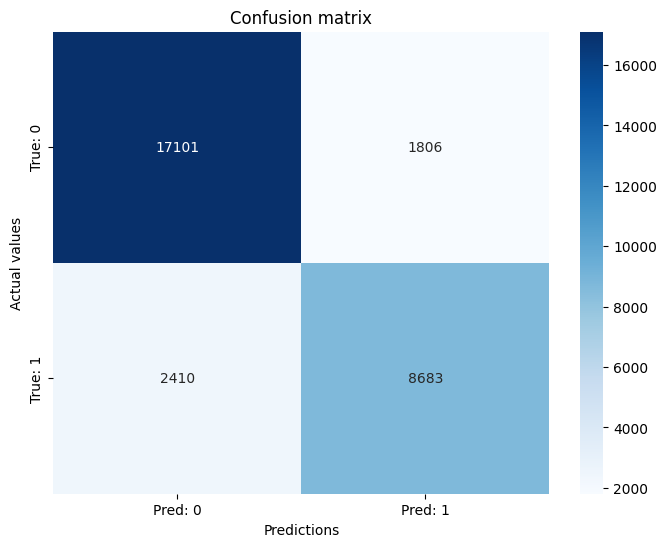

AUC train: 0.9328907014789778
AUC test: 0.9344623405903566


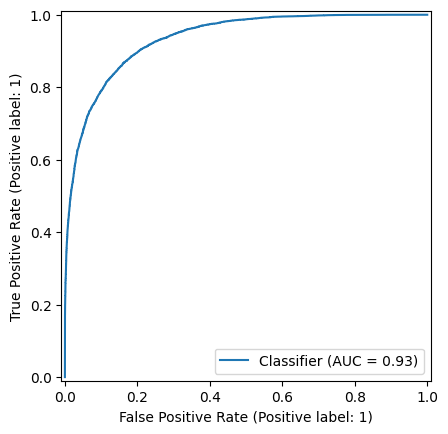

In [ ]:
X_vars = health_variables + lifestyle_variables
model = xgb.XGBClassifier(**best_hyperparams)
y_pred = prediction_evaluation(
    X_train[X_vars],
    X_test[X_vars],
    y_train,
    y_test,
    model
)